<a href="https://colab.research.google.com/github/Ben-069/DataManPy/blob/main/PS0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DATA MANAGEMENT 2026
#URBAN AGRICULTURE AND AND LIFE SATISFACTION IN PARAGUAY
//Author: Benito Ortega Torres
//Affiliation: Departament of Public Policy and Administration - Rutgers University - Camden
//Program: Public Affairs and Community Development PhD.

##URBAN GARDENING IN NJ
incomplete dataset :'(

In [1]:
import requests
import pandas as pd

In [4]:
base_url = "https://services1.arcgis.com/ze0XBzU1FXj94DJq/ArcGIS/rest/services/NJ_Urban_Agriculture_WFL1/FeatureServer/0"

query_url = base_url + "/query"

params = {
    "where": "1=1",          # Todas las observaciones
    "outFields": "*",        # Todas las variables
    "returnGeometry": "false",
    "f": "json"
}
response = requests.get(query_url, params=params)
response.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)
data = response.json()

In [8]:
# Convertir los atributos a DataFrame
df = pd.DataFrame(
    [feature["attributes"] for feature in data["features"]]
)

df.head()

,OBJECTID,Site_Name,Site_Class,Address,City,Active,Latitude,Longitude,Outdoor_Prod,Indoor_Prod,...,Education,Entrepr_Commercial,Personal_HomeUse,Therapeutic_Spiritual_Meditatio,Ownership,Preserved,Soil_Testing,NOTE,Lat,Long
0,1,Sister Jeans Garden,Community Garden,108 N. Pennsylvania Avenue,Atlantic City,Yes,39.365669771438,-74.42619222149581,,,...,,,,,,,,,39.36567,-74.42619
1,2,ARC Community Garden,Community Garden,1311 N. Main Street,Pleasantville,Yes,39.4118236,-74.50519750000001,,,...,,,,,,,,,39.41182,-74.50520
2,3,Hamilton Memorial Community Garden,Community Garden,605-11 Arctic Avenue,Atlantic City,Yes,39.36781328516018,-74.41932374596328,,,...,,,,,,,,,39.36781,-74.41933
3,4,Mill Creek Urban Farm,Urban Farm,"75 Mill Street, Bridgteon NJ 08302",Bridgeton,Yes,39.4269653521598,-75.22834811576081,Yes,Yes,...,Yes,Yes,,,Public,N,Y,Multiple greenhouses with a focus on hydroponics,39.42696,-75.22835
4,5,Parkside Learning Garden,Community Garden,1221 Hadden Avenue,Camden,Yes,39.9316181,-75.1023684,,,...,,,,,,,,,39.93162,-75.10237


In [9]:
df.shape

(287, 24)

In [36]:
from google.colab import files

df.to_csv("NJ_Urban_Agriculture.csv", index=False)
files.download("NJ_Urban_Agriculture.csv")

NameError: name 'df' is not defined

##NYC GARDEN DATA
How are land characteristics and physical resources distributed across community gardens in New York City?

Source:https://data.cityofnewyork.us/dataset/GreenThumb-Garden-Info/p78i-pat6/data_preview

In [1]:
import pandas as pd

host = "data.cityofnewyork.us"

garden_url = (
    "https://" + host +
    "/resource/p78i-pat6.csv?$limit=50000"
)

gardens = pd.read_csv(garden_url)

print(gardens.shape)
gardens.head()

(635, 27)


,assemblydist,address,borough,communityboard,congressionaldist,coundist,gardenname,juris,multipolygon,openhrsf,...,policeprecinct,statesenatedist,status,zipcode,bbl,nta,censustract,lat,lon,crossstreets
0,81,435 East 238th Street,X,212,15,11,Growing Good Community Garden,PRI,MULTIPOLYGON (((-73.86374480318754 40.90039177...,11:00 a.m - 6:00 p.m.,...,47,36,Active,10470,2.033920e+09,BX62 /,451.02,40.900243,-73.863808,NaN
1,78,2827 Decatur Ave,X,207,13,15,Oliver's Place,DOT,MULTIPOLYGON (((-73.88595238630586 40.86740172...,NaN,...,52,33,Not GreenThumb,10458,NaN,BX05 /,407.02,40.867004,-73.885891,East 198th and East 199th Streets
2,84,128 Lincoln Avenue,X,201,14,8,Maria Sola Green Space,NYS DOT,MULTIPOLYGON (((-73.92836835468306 40.80842338...,NaN,...,40,29,Not GreenThumb,10454,NaN,BX39 /,19.01,40.808148,-73.929210,NaN
3,79,345 East 153rd Street,X,201,15,17,Melrose Houses Community Garden - Melrose Hous...,NYCHA,MULTIPOLYGON (((-73.91843008455554 40.82142702...,10:00 A.M. - 11:310:00 A.M.- 11:30 A.M & 3:00 ...,...,40,29,Active,10451,2.024130e+09,BX34 /,67.00,40.820762,-73.919546,Morris Ave and courtland ave
4,83,3601 Marolla Place,X,212,16,12,Ujamaa Northeast Community Garden,DOT,MULTIPOLYGON (((-73.83487576713033 40.88368301...,NaN,...,47,36,Active,10466,2.049220e+09,BX03 /,484.01,40.884047,-73.834892,NaN


In [37]:
from google.colab import files

gardens.to_csv("NYC_urban_agr.csv", index=False)
files.download("NYC_urban_agr.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
print(gardens.head())

print(gardens.columns)

print(gardens.info())

   assemblydist                address borough  communityboard  \
0            81  435 East 238th Street       X             212   
1            78       2827 Decatur Ave       X             207   
2            84     128 Lincoln Avenue       X             201   
3            79  345 East 153rd Street       X             201   
4            83     3601 Marolla Place       X             212   

   congressionaldist  coundist  \
0                 15        11   
1                 13        15   
2                 14         8   
3                 15        17   
4                 16        12   

                                          gardenname    juris  \
0                      Growing Good Community Garden      PRI   
1                                     Oliver's Place      DOT   
2                             Maria Sola Green Space  NYS DOT   
3  Melrose Houses Community Garden - Melrose Hous...    NYCHA   
4                  Ujamaa Northeast Community Garden      DOT   

       

In [4]:
gardens = gardens[
    [
        "parksid",
        "gardenname",
        "borough",
        "zipcode",
        "status",
        "juris",
        "nta",
        "censustract",
        "lat",
        "lon"
    ]
].copy()

In [5]:
print(gardens.duplicated().sum())

gardens = gardens.drop_duplicates()

print(gardens.shape)

1
(634, 10)


In [6]:
missing = (
    gardens.isna()
    .sum()
    .sort_values(ascending=False)
)

print(missing)

lon            56
lat            56
censustract    56
parksid         0
gardenname      0
borough         0
juris           0
status          0
zipcode         0
nta             0
dtype: int64


In [7]:
missing_pct = (
    gardens.isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(missing_pct)


lon            8.83
lat            8.83
censustract    8.83
parksid        0.00
gardenname     0.00
borough        0.00
juris          0.00
status         0.00
zipcode        0.00
nta            0.00
dtype: float64


In [8]:
print(gardens["borough"].value_counts())

print(gardens["status"].value_counts())

print(gardens["juris"].value_counts())

print(gardens["zipcode"].nunique())

print(gardens["nta"].nunique())

borough
B    267
M    163
X    134
Q     58
R     12
Name: count, dtype: int64
status
Active                      546
Not GreenThumb               65
Inactive (No Group)           8
Closed (Construction)         6
Active (Unlicensed)           4
Inactive (Group Forming)      3
Closed (Other)                2
Name: count, dtype: int64
juris
DPR           395
NYRP           49
NYCHA          36
BQLT           36
PRI            32
BLT            18
MLT            12
DOT            10
DOE             6
DPR/PRI         5
BANG            5
MTA             4
NYS DOT         3
PRI / DOT       2
JOP             2
DEP             2
NYPD (DPR)      2
DEP (DPR)       2
DPR/MLT         2
DOT/MTA         1
DPR/MTA         1
DOE (DPR)       1
DPR/NYRP        1
ACS/PRI         1
NYS PARKS       1
HPD             1
MTA/BQLT        1
DPR/FDNY        1
DCAS (DPR)      1
DCAS            1
Name: count, dtype: int64
104
97


###Descriptive Statistics

In [9]:
# Number of observations and variables
print("Number of observations:", gardens.shape[0])
print("Number of variables:", gardens.shape[1])

Number of observations: 634
Number of variables: 10


In [10]:
borough_counts = gardens["borough"].value_counts()
borough_pct = gardens["borough"].value_counts(normalize=True) * 100

borough_table = pd.DataFrame({
    "Frequency": borough_counts,
    "Percent": borough_pct.round(2)
})

print(borough_table)

         Frequency  Percent
borough                    
B              267    42.11
M              163    25.71
X              134    21.14
Q               58     9.15
R               12     1.89


Interpretation:
-Community gardens are unevenly distributed across New York City.Brooklyn -contains the largest share of gardens, with about 42% of
-all observations, followed by Manhattan and the Bronx.
-Staten Island has substantially fewer gardens than the other boroughs.

In [11]:
#status percentage
status_counts = gardens["status"].value_counts()
status_pct = gardens["status"].value_counts(normalize=True) * 100

status_table = pd.DataFrame({
    "Frequency": status_counts,
    "Percent": status_pct.round(2)
})

print(status_table)

                          Frequency  Percent
status                                      
Active                          546    86.12
Not GreenThumb                   65    10.25
Inactive (No Group)               8     1.26
Closed (Construction)             6     0.95
Active (Unlicensed)               4     0.63
Inactive (Group Forming)          3     0.47
Closed (Other)                    2     0.32


Interpretation
The data shows that 86.12% of the gardens in the dataset are currently active. 10% appears as not part of the greenthumb program. The remaining categories correspond to gardens in the categories of inactive, closed, active but inormal (unlicensed).

In [12]:
#a basic graph

In [13]:
import matplotlib.pyplot as plt

# Convert borough codes to full names
borough_names = {
    "B": "Brooklyn",
    "M": "Manhattan",
    "X": "Bronx",
    "Q": "Queens",
    "R": "Staten Island"
}

gardens["borough_name"] = gardens["borough"].map(borough_names)

# Count gardens by borough
borough_counts = gardens["borough_name"].value_counts()

print(borough_counts)

borough_name
Brooklyn         267
Manhattan        163
Bronx            134
Queens            58
Staten Island     12
Name: count, dtype: int64


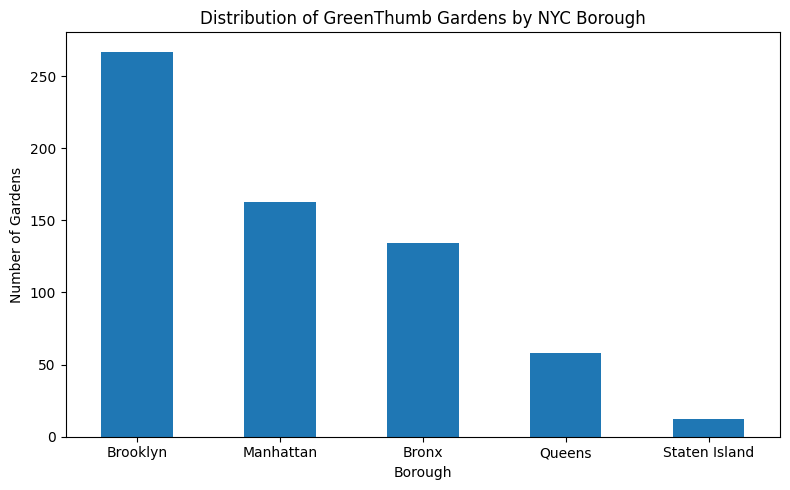

In [14]:
# Community Gardens by Borough
borough_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of GreenThumb Gardens by NYC Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Gardens")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

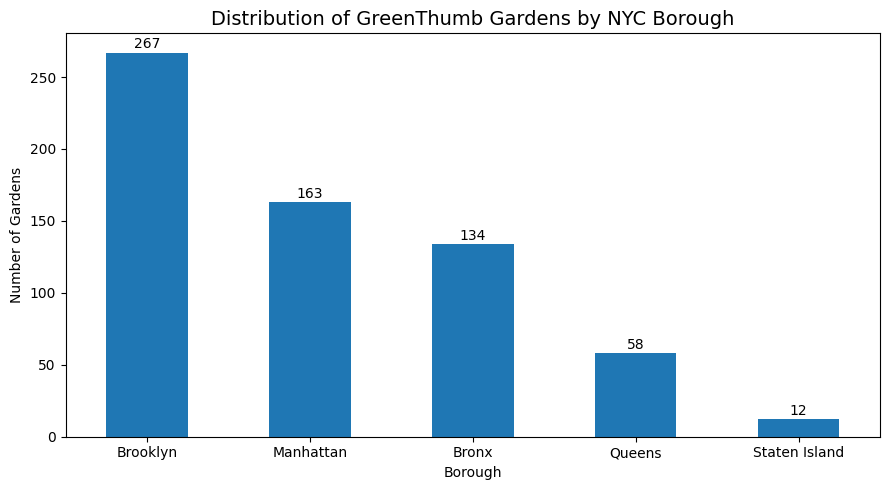

In [15]:
import matplotlib.pyplot as plt

borough_counts = gardens["borough_name"].value_counts()

ax = borough_counts.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Distribution of GreenThumb Gardens by NYC Borough",
    fontsize=14
)

plt.xlabel("Borough")
plt.ylabel("Number of Gardens")
plt.xticks(rotation=0)

# Add numbers above bars
for i, value in enumerate(borough_counts):
    ax.text(
        i,
        value + 3,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

Figure 1.2 shows the the gardes distribution across the 5 boroughs in NYC. We can observe that most of the gardens are located in Brooklyn

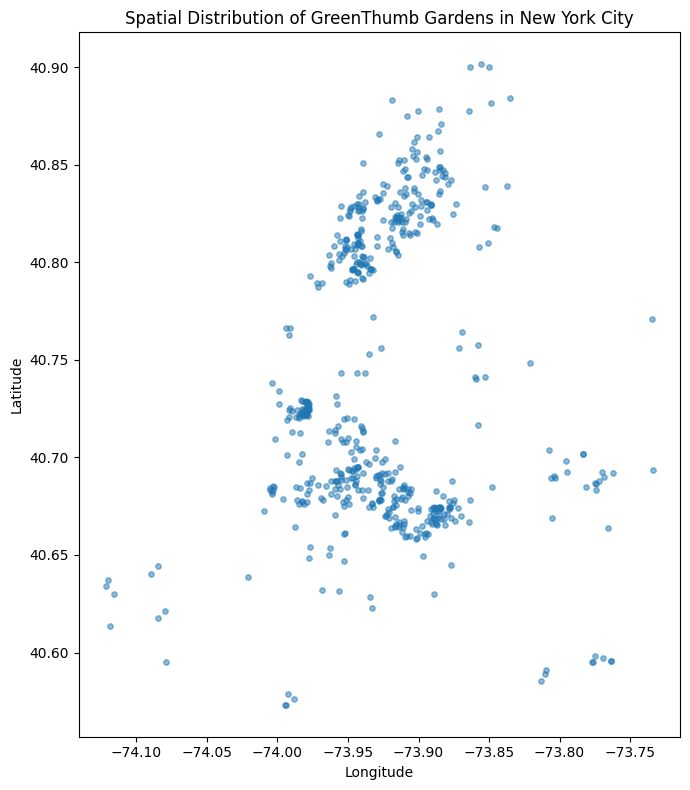

In [25]:
plt.figure(figsize=(7, 8))

plt.scatter(
    gardens["lon"],
    gardens["lat"],
    alpha=0.5,
    s=15
)

plt.title("Spatial Distribution of GreenThumb Gardens in New York City")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

#LIFE SATISFACTION IN PARAGUAY

For this piece of my project I am plannig using data from https://www.latinobarometro.org/, I will use survey data from 2013 to 2024 to see how life satisfaction varies across the years that te survey were conducted in Paraguay. I am aiming to see what is what has more impact on life satisfaction in the country.